# Radiative transfer in 1D

This notebook contains some code and exercises to compute radiation quantities from 1D model atmospheres.


In [16]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy
import matplotlib.pyplot as plt
from matplotlib import cm
from astropy import units
from astropy import constants
from astropy.modeling.models import BlackBody
from astropy.table import QTable  # to use tables with units
from scipy.special import wofz

# Plot defaults and quantity support
from astropy.visualization import quantity_support
quantity_support();

i_units = units.Quantity(1, unit='kW m-2 nm-1 sr-1')

## 1. The Schuster-Schwarzschild atmosphere

The Schuster-Schwarzschild is a very simplified atmosphere model with only two parts: a *surface* and a *layer* (region above the surface). Each of these regions is considered to have constant properties (temperature, extinction, etc.) and in thermodynamical equilibrium. The only thing that can vary is the temperature of each layer. We've seen before that in these cases, the intensity coming out of the optically thick atmosphere is given by

\begin{equation} 
  I_\lambda = B_\lambda(T_{\rm surface}) \mathrm{e}^{-\tau_\lambda} 
        + B_\lambda(T_{\rm layer}) \, \left( 1 - \mathrm{e}^{-\tau_\lambda} \right).
\end{equation}

And for simplicity, we obtained the optical depth $\tau_\lambda$ not by including all detailed radiative processes, but by just including a line profile $V(a,u)$ multiplied by a constant $\tau(0)$, which effectively determines the strength of the spectral line:


\begin{equation}
   \tau(u) = \tau(0)\,\, V(a,u).
\end{equation}

We coded $V(a,u)$ as:

In [2]:
def voigt(damping, u):
    """
    Calculates the Voigt function.
    """
    z = (u + 1j * damping)
    return wofz(z).real

And wrote the function to compute the Schuster-Schwarzschild profile as

In [3]:
def compute_profile(tau0, a, u, wavelength):
    wave = wavelength[numpy.newaxis, numpy.newaxis]
    tau = tau0[numpy.newaxis] * voigt(a, u[:, numpy.newaxis])
    tau = tau[..., numpy.newaxis]
    result = (BlackBody(temp_surface, scale=i_units)(wave) * numpy.exp(-tau) +
              BlackBody(temp_layer, scale=i_units)(wave) * (1 - numpy.exp(-tau)))
    return numpy.squeeze(result)

This function has a lot of broadcasting, which is overkill for simple cases but will come in handy later on. A simple line profile in absorption can be computed by setting the temperature of the layer to be larger than the surface, and a few other appropriate parameters:

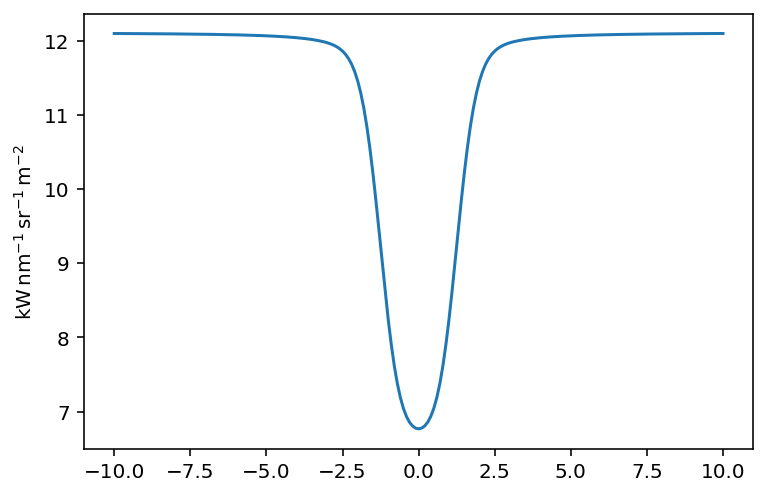

In [6]:
temp_surface = 5000 * units.K
temp_layer = 4500 * units.K
tau0 = numpy.array([3])  # thickness of reversing layer
wave = units.Quantity(500, unit='nm')
u = numpy.linspace(-10, 10, 201)
a = 0.1

intensity = compute_profile(tau0, a, u, wave)

fig, ax = plt.subplots()
ax.plot(u, intensity);

## 2. Line strength and curve of growth

How does one define the strength of a spectral line? For an absorption line, this could be how deep the line core reaches (the deeper, the stronger the line). But then you could have two lines with the same depth but different broadening, so one could say that the broader line is stronger. Therefore, it is more accurate to measure the line strength as the integrated area from the line wings to the line core. This measure is called the equivalent width $W_\lambda$, and can be illustrated in the following image:

<img src="https://tiagopereira.space/ast4310/images/eqw.svg" alt="Radiation through a layer" width="500"/>

It measures the integrated line depression in the normalized spectrum:

\begin{equation} \tag{13}
   W_\lambda \equiv \int 1 - \frac{I(\lambda)}{I_{\rm cont}}
               {\rm d} \lambda,
\end{equation}

so that its value is the same as the width of a rectangular piece of spectrum that blocks the same amount of spectrum completely. One can also define it for emission lines, and then you measure the positive area, so

\begin{equation} \tag{13}
   W_\lambda \equiv \int \frac{I(\lambda)}{I_{\rm cont}}
               {\rm d} \lambda.
\end{equation}

The equivalent width has units of wavelength, and for most lines it is typically in the range of pm.

The curve of growth is a plot of $W_\lambda$ vs the amount of extinction of optical depth. It was a popular tool to measure element abundances by first deriving the theoretical curve, and then comparing to observations of equivalent widths of lines of a given element. By adjusting the x scale (extinction, linearly dependend on abundance) one would derive the element abundance. It has been superseeded by more modern methods, but still has pedagogical value to understand how the strength of spectral lines evolves with extinction.


### Exercises

* Using a=0.01, and a range of `tau0 = numpy.logspace(-1, 5, 61)`, compute the equivalent widths for spectral lines in a Schuster-Schwarzschild atmsphere with $T_{\rm layer}$=5000 K and $T_{\rm surface}$=6000 K. Then plot the resulting curve of growth.
* The first part has slope 1:1, the third part has slope 1:2 in this log-log plot.  Why?

* Which parameter controls the location of the onset of the third part? Give a rough estimate of its value for solar iron lines through comparison with the given figure from Wright (1948).

* Which parameter should you increase to produce emission lines instead of absorption lines? Change it accordingly and modify the code to produce emission profiles and an emission-line curve of growth. (To avoid taking the log of negative $W_\lambda$, plot the absolute value of $W_\lambda$.)

In [7]:
# Your answers here

## 3. A 1D static atmosphere

The Schuster-Schwarzschild is a poor approximation to a stellar atmosphere. A better model is to assume that temperature and other quantities vary with depth, and model more layers. Such 1D models are still widely used today, and a popular one for the solar atmosphere is the 1D FALC model by 
[Fontenla et al. (1993)](http://adsabs.harvard.edu/abs/1993ApJ...406..319F).
They derived this description of the solar photosphere and chromosphere empirically, assuming that the solar atmosphere is horizontally homogeneous ("plane parallel layers") and in hydrostatic equilibrium ("time independent").

The FALC model is given in the `falc.dat` file. We can load the file into a useful `astropy.table.QTable` object with the correct units using the metadata in the file:

In [17]:
def read_table_units(filename):
    """
    Reads a table in a text file, formatted with column names in first row,
    and unit names on second row. Any deviation from this format will fail.
    """
    tmp = numpy.genfromtxt(filename, names=True)
    unit_names = open(filename).readlines()[1][1:].split()
    # Convert to astropy QTable to have units
    data = QTable(tmp)
    # Assign units to quantities in table, use SI units
    for key, unit in zip(data.keys(), unit_names):
        data[key].unit = unit
        data[key] = data[key].si  # We don't want to use deprecated units
    return data

In [18]:
falc = read_table_units("falc.dat")
falc

height,tau_500,colmass,temperature,v_turb,hydrogen_density,proton_density,electron_density,pressure,p_ratio,density
m,,kg / m2,K,m / s,1 / m3,1 / m3,1 / m3,N / m2,,kg / m3
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2218200.0,0.0,6.777e-05,100000.0,11730.0,5574999999999999.0,5574999999999999.0,6664999999999999.0,0.01857,0.952,1.3059999999999998e-11
2216500.0,7.696e-10,6.779e-05,95600.0,11650.0,5837999999999999.0,5836999999999999.0,6946999999999999.0,0.01857,0.95,1.3679999999999998e-11
2214890.0,1.531e-09,6.781e-05,90816.0,11560.0,6150999999999999.0,6149999999999999.0,7283999999999999.0,0.01858,0.948,1.4409999999999997e-11
2212770.0,2.597e-09,6.785e-05,83891.0,11420.0,6667999999999999.0,6666999999999999.0,7833999999999999.0,0.018590000000000002,0.945,1.562e-11
2210640.0,3.754e-09,6.788000000000001e-05,75934.0,11250.0,7380999999999999.0,7377999999999999.0,8575999999999999.0,0.018600000000000002,0.941,1.729e-11
2209570.0,4.384e-09,6.79e-05,71336.0,11140.0,7863999999999999.0,7857999999999999.0,9075999999999998.0,0.018600000000000002,0.938,1.8429999999999998e-11
...,...,...,...,...,...,...,...,...,...,...
-40000.0,2.946,55.67,7590.0,1730.0,1.2799999999999998e+23,4.2489999999999993e+20,4.4799999999999993e+20,15250.0,0.971,0.0003


The first column specifies the height $h$
which is the distance above $\tau_{500}$ =1 where
$\tau_{500}$, given in the second column, 
is the radial optical depth in the continuum at 
$\lambda$ = 500 nm. The quantity `colmass` in the third column is the 
mass of a column with cross-section of 1 m$^2$ above the given
location.  

In the photosphere ($-$100 $\leq h\leq$ 525 km) and chromosphere (525 $\leq h\leq$ 2100 km) the temperature $T$ (fourth column) has been
adjusted empirically so that the computed spectrum is in agreement
with the spatially averaged disk-centre spectrum observed from quiet 
solar areas (away from active regions). The temperature distribution
in the transition region (above $h\approx$ 2100 km, up to $T$ = 10$^5$ K) has been determined theoretically by balancing the downflow of energy from the corona through thermal conduction and diffusion against the radiative energy losses.

The microturbulence or turbulent velocity `v_turb` is a "fudge factor" to compensate for the lack of Doppler broadening in a 1D model. It has been adjusted at each height to accounts for the observed Doppler broadening of lines formed at various heights. It can compensate for the width of the lines, but cannot describe the observed line asymmetries that arise from velocities at different heights.

The total pressure $P_{\rm tot}$ is the sum of the gas pressure
$P_{\rm gas}$ and the corresponding turbulent pressure $\rho \, v_\mathrm{turb}^{2}/2$ where $\rho$
is the gas density (last column).

The table also lists the total hydrogen density $n_{\rm H}$ (`hydrogen_density`, which includes both neutral hydrogen and protons), the
free proton density $n_{\rm p}$ (`proton_density`),
and the free electron density $n_{\rm e}$ (`electron_density`).   Given the $T$ and $v_\mathrm{turb}$ distributions with height,
these number densities and other quantities 
were determined by requiring hydrostatic equilibrium and 
evaluating the ionisation balances
by solving the coupled radiative transfer 
and statistical equilibrium equations (without assuming LTE).
The adopted helium-to-hydrogen abundance ratio is 
$N_{\rm He}/N_{\rm H} = 0.1$. The relative abundances of the other elements came from [Asplund et al. (2009)](http://adsabs.harvard.edu/abs/2009ARA%26A..47..481A).


Because this is a 1D static model, it is meant to reproduce the time- and space-averaged atmosphere of the Sun. Many people take this model as a true representation of the average Sun. This is wrong. It is at best a "spectroscopically-equivalent" model of the average Sun, meaning that the radiation and spectral lines computed from this model match the time and space-averaged spectral lines observed on the Sun. The temporal and spatial inhomogeneities in the surface of the Sun mean that no 1D cut through the atmosphere is reproduced by the FALC model. To accurately describe the complex solar atmosphere, a 3D model is needed (used in detail in *Project 6: 3D line formation*).

Each quantity in the `QTable` can be accessed by its label, e.g. `falc['temperature']`. Here is a plot of the FALC temperature stratification in the range of temperatures where most of the radiation escapes:

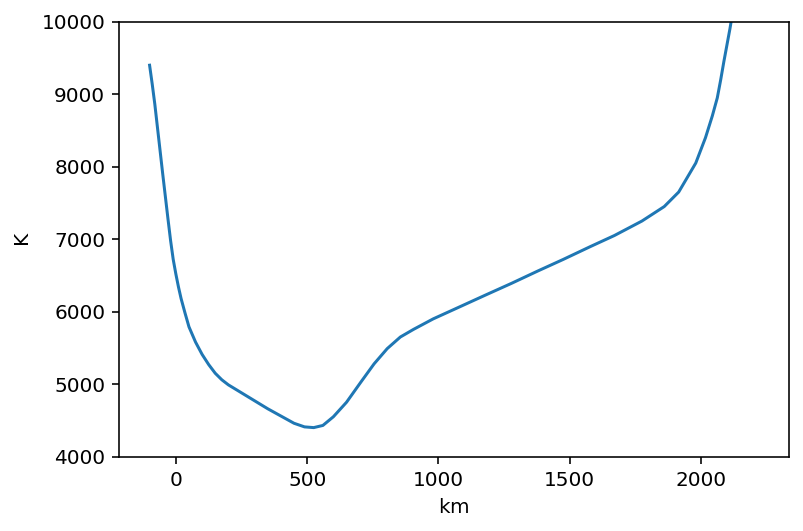

In [19]:
fig, ax = plt.subplots()
ax.plot(falc['height'].to('km'), falc['temperature'])
ax.set_ylim(4000, 10000);

## 4. Continuum extinction

Here we will define tools to compute continuum extinction using two main processes: bound-free and free-free from the H$^-$ ion (the dominant source in cool stellar atmospheres), and Thomson scattering.

Thomson scattering from electrons is wavelength independent, and its cross section is given by:

$$
\sigma^T=\frac{8\pi}{3}r_e^2\approx 6.648 \times 10^{-29}\;\; \mathrm{m}^2.
$$

To obtain the linear extinction $\alpha^T$ we need to multiply it by the electron density $n_e$.

The extinction from H$^-$ has no clear analytical form, and we must use laboratory measurements to include it properly. We'll use the recipe coded below:

In [8]:
def cross_section_hminus_bf(wavelength, temperature):
    """
    Gets the H^- bound-free cross section using the recipes of
    Wishart (1979) and Broad and Reinhardt (1976).
    
    Parameters
    ----------
    wavelength : astropy.units.quantity (scalar or array)
        Wavelength to calculate in units of length.
    temperature: astropy.units.quantity (scalar or array)
        Gas temperature in units of K or equivalent.
        
    Returns
    -------
    cross_section : astropy.units.quantity (scalar or array)
        cross section (in m^2) per H^- ion.
    """
    wbr_λ = numpy.array(
        [  18, 19.6, 21.4, 23.6, 26.4, 29.8, 34.3, 40.4, 49.1, 62.6,  121, 139,
          164,  175,  200,  225,  250,  275,  300,  325,  350,  375,  400, 425,
          450,  475,  500,  525,  550,  575,  600,  625,  650,  675,  700, 725,
          750,  775,  800,  825,  850,  875,  900,  925,  950,  975, 1000, 1025,
         1050, 1075, 1100, 1125, 1150, 1175, 1200, 1225, 1250, 1275, 1300, 1325,
         1350, 1375, 1400, 1425, 1450, 1475, 1500, 1525, 1550, 1575, 1600, 1610,
         1620, 1630]
    ) * units.nm  # in nm
    wbr_σ = numpy.array(
        [0.067, 0.088, 0.117, 0.155, 0.206, 0.283, 0.414, 0.703,  1.24,  2.33,
          5.43,  5.91,  7.29, 7.918, 9.453, 11.08, 12.75, 14.46, 16.19, 17.92,
         19.65, 21.35, 23.02, 24.65, 26.24, 27.77, 29.23, 30.62, 31.94, 33.17,
         34.32, 35.37, 36.32, 37.17, 37.91, 38.54, 39.07, 39.48, 39.77, 39.95,
         40.01, 39.95, 39.77, 39.48, 39.06, 38.53, 37.89, 37.13, 36.25, 35.28,
         34.19, 33.01, 31.72, 30.34, 28.87, 27.33, 25.71, 24.02, 22.26, 20.46,
         18.62, 16.74, 14.85, 12.95, 11.07, 9.211, 7.407, 5.677, 4.052, 2.575,
         1.302, 0.8697, 0.4974, 0.1989]
    ) * 1e-22 * units.m**2
    sigma = numpy.interp(wavelength, wbr_λ, wbr_σ)
    # correct for stimulated emission
    sigma = sigma *  (1 - numpy.exp(-constants.h * constants.c /
                                    (wavelength * constants.k_B * temperature)))
    return sigma
    

def cross_section_hminus_ff(wavelength, temperature):
    """
    Gets the H^- free-free cross section coefficient using the recipe
    of John (1988). Includes stimulated emission.
    
    Parameters
    ----------
    wavelength : astropy.units.quantity (scalar)
        Wavelength to calculate in units of length.
    temperature: astropy.units.quantity (scalar or array)
        Gas temperature in units of K or equivalent.
        
    Returns
    -------
    cross_section : astropy.units.quantity (scalar or array)
        H^- ff cross section coefficient (in m^5) per neutral hydrogen atom per electron.
    """
    table = numpy.array([
        [    0.0000,     0.0000,      0.0000,      0.0000,     0.0000,    0.0000],
        [ 2483.3460,   285.8270,  -2054.2910,   2827.7760, -1341.5370,  208.9520],
        [-3449.8890, -1158.3820,   8746.5230, -11485.6320,  5303.6090, -812.9390],
        [ 2200.0400,  2427.7190, -13651.1050,  16755.5240, -7510.4940, 1132.7380],
        [ -696.2710, -1841.4000,   8624.9700, -10051.5300,  4400.0670, -655.0200],
        [   88.2830,   444.5170,  -1863.8640,   2095.2880,  -901.7880,  132.9850]]
    ) 
    sqrtθ = numpy.sqrt(5040 / temperature.to_value("K"))
    wave_mu = wavelength.to_value("um")
    wave_inv = 1. / wave_mu
    kappa = 0.
    for i in range(6):
        kappa += sqrtθ**(i + 2) * (wave_mu**2 * table[i, 0] + table[i, 1] +
                       wave_inv * (table[i, 2] + wave_inv * (table[i, 3] +
                       wave_inv * (table[i, 4] + wave_inv * table[i, 5]))))
    kappa = kappa * 1e-32 * units.m**4 / units.N  # Put units from table
    return (kappa * constants.k_B * temperature).to("m^5")  

To obtain linear extinction, these cross sections need to be multiplied by different quantities. One needs to be multiplied by the density of neutral hydrogen, the other by the density of H$^-$ ions. We will use Saha for both, and will code everything in the functions below:

In [9]:
def compute_h_neutral_frac(temperature, electron_density):
    """
    Computes the fraction of neutral hydrogen for a given temperature
    and electron density.
    """
    chi_H = 2.1787094174620437 * units.aJ
    saha_const = ((2 * numpy.pi * constants.m_e * constants.k_B) / constants.h**2)**1.5
    saha = (saha_const * temperature**1.5 / electron_density * 
            numpy.exp(-chi_H / (constants.k_B * temperature)))
    return 1 / (1 + saha)

def compute_hminus_frac(temperature, electron_density):
    """
    Computes the fraction of H- divided by neutral hydrogen for a 
    given temperature and electron density.
    """
    chi_Hminus = 0.12080412 * units.aJ
    saha_const = ((2 * numpy.pi * constants.m_e * constants.k_B) / constants.h**2)**1.5
    saha = (4 * saha_const * temperature**1.5 / electron_density * 
            numpy.exp(-chi_Hminus / (constants.k_B * temperature)))
    return 1 / saha

def compute_α_cont(wavelength, temperature, electron_density,
                   h_density, h_minus=None):
    """
    Computes continuum extinction coefficient α using
    Thomson scattering plus the H- bf and ff extinction.
    """
    h_neutral = h_density * compute_h_neutral_frac(temperature, electron_density)
    if h_minus is None:
        # If not provided, compute from neutral hydrogen
        h_minus = h_neutral * compute_hminus_frac(temperature, electron_density)
    alpha_bf = cross_section_hminus_bf(wavelength, temperature) * h_minus
    alpha_ff = cross_section_hminus_ff(wavelength, temperature) * h_neutral * electron_density
    alpha_thomson = 6.648e-29 * units.m ** 2 * electron_density
    return alpha_bf + alpha_ff + alpha_thomson

### Exercises

* Split the function `compute_α_cont` into three functions so you can get separate outputs for $\alpha_{bf}$ and $\alpha_{ff}$ from H$^-1$, and $\alpha_T$ from Thomson scattering. Compute them all for wavelengths between 300-2000 nm, and for the temperature and density at the solar surface (height = 0) in the FALC model. Plot the result and discuss.
    
* Hydrogenic bound-free edges behave just as H$^-$ with maximum extinction at the ionisation limit and decay $\sim \lambda^3$ for smaller wavelengths, as indeed shown by the H$^-$ curve. The H$^-$ bound-free extinction differs strongly from this pattern. Why is it not hydrogenic although due to hydrogen?

* Compute and plot $\alpha_\lambda^c$ from H$^-$ as a function of height for the FALC model, at $\lambda$ = 0.5 μm. This plot needs to be logarithmic in y, why?

* Now add the Thomson scattering off to the extinction coefficient $\alpha_\lambda^c$. Plot the total $\alpha_\lambda^c=\alpha_\lambda^{H-} + \alpha^T$ as well as the separate components for H$^-$ and Thomson scattering at 0.5 μm as a function of height for the FALC model. Discuss.
    
* The photon scattering probability, let's call it $\zeta_\lambda$, gives the probability that a photon will be scattered (instead of absorbed) when it interacts with another particle. It can be defined as:
\begin{equation*}
        \zeta_\lambda = \frac{\alpha_\lambda^s}{\alpha_\lambda^a+\alpha_\lambda^s},
\end{equation*} 
    where $\alpha_\lambda^s$ is the extinction from scattering processes and $\alpha_\lambda^a$ is the extinction from absorption processes. Assuming that all H$^-$ extinction results only in absorption, plot $\zeta_\lambda$ at 0.5 μm as a function of height for the FALC model, using only the extinction sources you've considered so far (H$^-$ and Thomson scattering). Discuss how this relates to the plot you made in the previous point.
</div>

## 5. Line extinction

We now have almost all the necessary ingredients to calculate synthetic spectra for a model atmosphere. The last remaining ingredient is the line extinction coefficient, $\alpha_\lambda^l$. The monochromatic line extinction per m path length for a bound-bound transition between a lower level $l$  and an upper level $u$ is given by (in SI units, see Rutten IART page 62):
\begin{equation*}
\alpha_\nu^l = \frac{e^2}{4\varepsilon_0 m_ec}n_l f_{lu} \varphi(\nu-\nu_0)\left[1 - \mathrm{e}^{-hc/\lambda k_B T}\right].
\end{equation*}

For the line profile we will assume a Voigt profile in wavelength units, $V(a, \lambda)\equiv H(a, u)/(\sqrt{\pi}\Delta\lambda_D)$, with the additional $\lambda^2 / c$ to convert from units per frequency to per wavelength, so the extinction becomes

\begin{equation*}
\alpha_\lambda^l = \frac{e^2}{4\varepsilon_0 m_ec}n_l f_{lu}\frac{\lambda^2}{c}\frac{H(a, u)}{\sqrt{\pi}\Delta\lambda_D}\left[1 - \mathrm{e}^{-hc/\lambda k_B T}\right].
\end{equation*}


The two main unknowns above are the lower level populations $n_l$ and the line profile $H(a, u)$, which we address below.


### 5.1 Level populations

The lower level populations $n_l$ are total number density of atoms in level $l$. An atomic level is related to $r$, a given ionisation stage (e.g. for a Na I line, $r=0$, for Na II, $r=1$, and so on). To obtain $n_l$, we first need to know $N_E$, the number density of atoms from element E, then how many of those are in ionisation stage $r$, and finally of those how many are in level $l$. $n_E$ is usually known by its ratio to the hydrogen number density, $N_H$. We can decompose $n_l$ in quantities that are more readily available:

\begin{equation*}
n_l = \frac{n_l}{N_E}\frac{N_E}{N_H}N_H.
\end{equation*}

$N_H$ is usually known from the model atmosphere, and $N_E/N_H$ is the abundance of the element relative to hydrogen. To make matters slightly confusing, astronomers usually define the abundance of an element not as $N_E/N_H$ but as a log quantity called $\epsilon_E$ or $A_E$:

\begin{equation*}
A_E \equiv \log_{10}\left(\frac{N_E}{N_H}\right) + 12.
\end{equation*}

Replacing in $n_l$ above, we get:
\begin{equation*}
n_l = \frac{n_l}{N_E} 10^{(A_E -12)}  N_H.
\end{equation*}

Since we are in LTE, the quantity $n_l/N_E$ is given by the combined Saha and Boltzmann distributions

\begin{eqnarray*}
   U_r 
   &\equiv& \sum_s g_{r,s} e^{-\chi_{r,s}/k_B T}
             \\
   \frac{n_{l}}{N_r}
   &=& \frac{g_{l}}{U_r} e^{-\chi_{l}/k_B T}
             \\
   \frac{N_{r+1}}{N_r}
   &=& \frac{1}{N_\mathrm{e}} \frac{2U_{r+1}}{U_r}
       \left(\frac{2 \pi m_\mathrm{e} k_B T}{h^2}\right)^{3/2} 
       e^{-\chi_r/k_B T},
\end{eqnarray*}

so that
\begin{equation*}
\frac{n_l}{N_E} = \frac{n_l}{N_r} \frac{N_r}{N_E},
\end{equation*}

where $n_l/N_r$ is given by the Boltzmann equation and $N_r/N_E$ (where $N_E = \sum_r N_r$) can be obtained by multiple runs of the Saha distribution, to obtain the ratios for all necessary states. This was what you did in Project 1. However, in that `Atom()` class you calculated the populations for all levels in all stages, which is overkill, especially when you have large atoms (e.g. Fe). It is more handy to compute $n_l/N_r$ only for the level of interest (the lower level of the spectral line), and only run the Saha sum for the most important ionisation stages.

Using the expression above for $n_l/N_r$ we get an expression that depends on the partition function $U_r(T)$, the lower level energy (or potential) $\chi_l$, and the statistical weight of the lower level $g_l$. The latter one is often combined in the ratio with $f_{lu}$ in the expression for $\alpha_\lambda$, so that we get:

\begin{equation}
\alpha_\lambda^l = \frac{e^2}{4\varepsilon_0 m_ec} g_l f_{lu} \frac{e^{-\chi_{l}/k_B T}}{U_r}  \frac{N_r}{N_E} 10^{(A_E -12)} N_H \frac{\lambda^2}{c}\frac{H(a, u)}{\sqrt{\pi}\Delta\lambda_D}\left[1 - \mathrm{e}^{-hc/\lambda k_B T}\right].
\end{equation}

The term $g_l f_{lu}$ ("gf-value") is often given in log form, $\log_{10}(gf)$, and is a measure of the transition strength. 

Here is a recipe to compute the partition function for Fe atoms. You can supply either a scalar temperature, or for more efficiency, an array:

In [10]:
def pfunction_Fe(temperature, stage=0):
    """
    Computes partition function for Fe I, Fe II, Fe III,
    depending on stage (Fe I: stage=0, Fe II: stage=1).
    
    Based on data from Gray (2005), p. 515.
    """
    θ = numpy.arange(0.2, 2.01, 0.2) 
    logU = numpy.array([
        [3.760, 2.049, 1.664, 1.519, 1.446, 1.402, 1.372, 1.350, 1.332, 1.317],
        [2.307, 1.881, 1.749, 1.682, 1.638, 1.604, 1.575, 1.549, 1.525, 1.504],
        [1.887, 1.518, 1.411, 1.370, 1.350, 1.337, 1.328, 1.320, 1.312, 1.304],
    ])
    θ_in = 5040. * units.K / temperature
    return 10. ** CubicSpline(θ, logU[stage])(θ_in)

To calculate $\alpha_\lambda^l$ (without the line profile), you will need a function similar to the one below:

In [ ]:
def compute_α_line(temperature, electron_density, h_density, doppler_width,
                            pfunction, wave0, loggf, χ, stage, abund): 
    """
    Compute line extinction without the profile.
    
    Parameters
    ----------
    temperature: astropy.units.quantity (scalar or array)
        Atmospheric temperature(s).
    electron_density: astropy.units.quantity (scalar or array)
        Electron density from atmosphere.
    h_density: astropy.units.quantity (scalar or array)
        Number density of hydrogen atoms (neutral and ionised).
    doppler_width: astropy.units.quantity (scalar or array)
        Doppler widths from atmosphere.
    pfunction: function
        Function to compute the partition function, for temperature and stage.
        E.g. pfunction_Fe or pfunction_Na.
    wave0: astropy.units.quantity (scalar)
        Rest wavelength of the bound-bound transition, in units of length.
    loggf: scalar
        log10(gf) for the transition.
    χ: astropy.units.quantity (scalar)
        Lower level energy of line.
    stage: scalar
        Ionisation scale. 0 for neutral, 1 for singly-ionised, and so on.
    abund: scalar
        Element abundance A(E) in usual scale, A(E)=log10(N_E/N_H)+12.
        
    Returns
    -------
    alpha_line: astropy.units.quantity (scalar or array)
        Line extinction without line profile
    """
    # Stimulated emission
    stim = (1 - numpy.exp(-constants.h * constants.c / 
                          (wave0 * constants.k_B * temperature)))  
    
    # WARNING: This function is incomplete, please finish this part.
    # Here you need to code Saha to compute N_r / N_E for your
    # element of choice and save it in the variable NrNe
      
    # populations divided by g
    n_l = (NrNe / pfunction(temperature, stage=stage) * 
           numpy.exp(-χ / constants.k_B / temperature) *
           10. ** (abund - 12) * h_density)
    # Constants in the formula for alpha
    alpha_const = constants.e.si ** 2 / (4 * constants.eps0 * constants.m_e * constants.c**2)
    # line extinction
    return alpha_const * wave0**2 * n_l * 10.**loggf / doppler_width * stim

### 5.2 Line Profile and Broadening

The Voigt function  $H(a,u)$ describes the extinction profile shape and is defined by:

\begin{eqnarray*}
   H(a,u) &\equiv& \frac{a}{\pi} \int_{-\infty}^{+\infty}
            \frac{e^{-y^2}}{(u - y)^2 + a^2} \mathrm{d} y
                           \\[1ex]
   y &=& \frac{v_\mathrm{los}}{c} \frac{\lambda_0}{\Delta \lambda_\mathrm{D}}\\
   u &=& \frac{\lambda-\lambda_0}{\Delta \lambda_\mathrm{D}}   
                           \\
   a &=& \frac{\lambda^2}{4\pi c}\frac{\gamma}{\Delta \lambda_\mathrm{D}},
\end{eqnarray*}

where $v_\mathrm{los}$ is the velocity along the line of sight and $a$ the damping parameter. The quantity $u$ is sometimes called the dimensionless wavelength, and is the wavelength difference from $\lambda_0$ divided by the Doppler width. In other words, it is a wavelength scale in terms of Doppler widths. When computing a line profile numerically, we need to decide which wavelengths to cover: how many points, and how far from the line core. Extending the wavelength range too much, and we are mostly computing continuum, which is a waste of time. But having a too narrow range means that we will miss out on the line wings, so that is not good either. Determining the wavelength range in terms of Doppler widths is more flexible, since it is independent of the line strength and $\lambda_0$. 

The Doppler width $\Delta \lambda_\mathrm{D}$ is not only set by the thermal broadening but in the 1D case it includes also the microturbulent "fudge parameter"  $v_\mathrm{turb}$ through defining it as:

\begin{equation*}
   \Delta \lambda_\mathrm{D} 
      \equiv \frac{\lambda_0}{c} \sqrt{\frac{2k_B T}{m_E} + v_\mathrm{turb}^2},
\end{equation*}
where $m_E$ is the mass of the atom that causes the spectral line.

To calculate the Voigt line profile, use the following functions:

In [12]:
def compute_doppler_width(wave0, temperature, mass, vturb):
    """
    Computes the Doppler width for a given temperature,
    mass of the atomic species, and turbulent velocity.
    Needs quantities with units.
    """
    return wave0 / constants.c * numpy.sqrt(2 * constants.k_B * 
                                            temperature / mass + vturb ** 2)


def compute_profile(wave, wave0, gamma, doppler_width):
    """
    Compute the line profile for a given broadening gamma
    and Doppler width.
    """
    damping = (wave**2 / (4 * numpy.pi * constants.c * doppler_width) * 
               gamma)
    u = ((wave - wave0) / doppler_width).to("")
    return voigt(damping, u)

The damping parameter $a$ contains the different types of line broadening in $\gamma$, often natural broadening, van der Waals broadening, and Stark broadening. Natural broadening is the sum of the Einstein coefficients for spontaneous de-excitation from the upper level of the transition to all levels below:

\begin{equation*}
   \gamma_\mathrm{rad} = \sum_{l<u}A_{ul}.
\end{equation*}

This quantity is usually tabulated in databases such as the [NIST Atomic Line Database](https://physics.nist.gov/PhysRefData/ASD/lines_form.html). Note that in the NIST database, 
$\gamma_\mathrm{rad}$ is listed as $A_{ki}$, or transition probability, in units of s$^{-1}$.


For the van der Waals broadening you will use the recipe of [Anstee & O'Mara (1995)](https://ui.adsabs.harvard.edu/abs/1995MNRAS.276..859A) (also known as ABO recipe). This is one of the most realistic recipes available to date, but is not available for all types of spectral lines. This recipe accounts for broadening from neutral hydrogen atoms:

\begin{equation*}
    \gamma_\mathrm{vdW} = 2\, a_0^2 \left(\frac{4}{\pi}\right)^{\alpha/2} \Gamma\left(\frac{4-\alpha}{2}\right)\bar{v}\,\sigma\, \left(\frac{\bar{v}}{10\;\mathrm{km/s}}\right)^{-\alpha}\; n_{\mathrm{HI}},
\end{equation*}


where $n_{\mathrm{HI}}$ is the number density of neutral hydrogen, $a_0$ is the Bohr radius (use `constants.a0`), $\Gamma$ is the Gamma function (use `scipy.special.gamma`), $\bar{v}$ is

\begin{equation*}
    \bar{v} = \left(\frac{8 k_B T}{\pi\mu_m} \right)^{1/2},
\end{equation*}

with $\mu_m$ the reduced mass of the two atoms, hydrogen and the line-producing element:

\begin{equation*}
    \mu_m = 1/\left(\frac{1}{m_\mathrm{H}} + \frac{1}{m_\mathrm{E}}\right).
\end{equation*}

Here, $m_\mathrm{E}=m_\mathrm{Na}$. The only remaining values are $\alpha$ and $\sigma$, which are tabulated in [Anstee & O'Mara (1995)](https://ui.adsabs.harvard.edu/abs/1995MNRAS.276..859A). To compute $\gamma_\mathrm{vdW}$ according to the ABO recipe, use the following function (the alpha and sigma are parameters that vary for each line):

In [13]:
def compute_gamma_ABO(temperature, h_neutral, alpha, sigma, mass):
    """
    Computes the van der Waals damping parameter for a bound-bound transition using
    the receipe of Barklem/O'Mara/Anstee. 
    
    Parameters
    ----------
    temperature: astropy.units.quantity (scalar or array)
        Gas temperature in units of K or equivalent.
    h_neutral: astropy.units.quantity (scalar or array)
        Number density of neutral hydrogen atoms, in m^-3 or equivalent.
        Same shape as temperature.
    alpha: scalar
        alpha parameter from Barklem/O'Mara/Anstee formalism.
    sigma: scalar
        sigma parameter from Barklem/O'Mara/Anstee formalism.
    mass: astropy.units.quantity (scalar)
        Mass of the atom producing the spectral line.
    """
    Ar_H = 1.007975  # Atomic weight of hydrogen
    mu_m = constants.u / (1 / Ar_H + 1 / (mass / constants.u))
    v_bar = numpy.sqrt(8 * constants.k_B * 1 * units.K / (numpy.pi * mu_m))
    v_ratio = (1e4 * units.m / units.s / v_bar).to('')
    const = (2 * constants.a0**2 * (4 / numpy.pi)**(alpha / 2) * 
             gamma((4 - alpha) / 2) * v_bar * sigma * v_ratio**alpha).to("m^3/s")
    return const * temperature.to_value("K") ** ((1 - alpha)/2) * h_neutral